# Notebook 024 — The Samuelson effect across 16 futures markets

The Samuelson (1965) hypothesis says futures return volatility rises as a contract
approaches expiry: information about near-term supply and demand decays by the time a
deferred contract expires, so the front of the curve reacts to news the back barely
feels. This notebook is a **descriptive, visual atlas** of that effect across every
futures market in this repo (16 products, 2010-2026) -- it fits no trading rule,
computes no Sharpe ratio, and spends no holdout.

Full spec: `NEXT_PROMPT.md`. Full narrative and numbers:
`src/results/024_samuelson_effect_across_futures.md`.


In [1]:
import json

TMP = "tmp"


def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)


prereg = load("phase_0_24_preregistration.json")
prereg["statement"]

'This notebook is a descriptive, visual atlas of the Samuelson (1965) maturity effect across all 16 futures markets in this repo. It fits no trading rule, computes no Sharpe ratio, and spends no holdout -- the full sample is used throughout, and there is no train/test split. Every number is a full-sample descriptive statistic.'

## Phase 0 — Pre-registration

This is a descriptive study: no holdout spent, no trading gate. The falsification condition, the estimator hierarchy, and the hygiene rules were fixed before any chart was looked at.

In [2]:
prereg["falsification_condition"]

"The study's central claim -- that realised volatility rises as a contract approaches expiry, and that this effect is strongest in storable commodities and weakest or absent in financial/precious-metal instruments -- would be FALSE if: (a) samuelson_slope is not reliably negative (with a bootstrap 95% CI excluding zero) in the energy and ag products under the primary MAD estimator; (b) the sign of the slope flips between the MAD and winsorised-std estimators for any product where the primary estimator finds a slope with a CI excluding zero; or (c) the sign flips across the max_gap in {1,3} or min_volume in {0,100,1000} liquidity variants for a headline product (CL, NG, GC, ES)."

In [3]:
prereg["predicted_ordering_confirmed_scoping_expectation"]

'Energy and grains strongly negative slope (vol rises toward expiry); precious metals (GC, SI) near zero or weakly positive; ES (negative control, no storage/convenience-yield economics) weakest of all commodities. This was already observed during scoping on 2026-09-22 (see NEXT_PROMPT.md section 3) using the exact method below -- it is recorded here as a CONFIRMED SCOPING EXPECTATION, not a blind pre-registered prediction, and the write-up says so explicitly. No pre-registration credit is claimed for having predicted something already measured.'

## Phase 1 — Panel construction and data-quality census

850,833 usable rows across 16 products after dropping `close <= 0` (this is the single most important section of the underlying prompt -- the far-dated end of every panel contains junk prints that destroy a plain standard deviation; see Phase 2 for the MAD-vs-std comparison).

In [4]:
phase1 = load("phase_1_24_panel_report.json")
for p in ["CL", "NG", "ES", "GC"]:
    d = phase1["products"][p]
    print(
        f"{p}: raw_rows={d['raw_rows']}, close<=0={d['close_le_0_count']}, "
        f"usable(gap1,vol0)={d['usable_returns_variants']['gap1_vol0']['n']}, "
        f"junk(|r|>1)={d['junk_prints_gt_1_log_return']['count']}"
    )

CL: raw_rows=109758, close<=0=391, usable(gap1,vol0)=81895, junk(|r|>1)=94
NG: raw_rows=144449, close<=0=14373, usable(gap1,vol0)=93612, junk(|r|>1)=58
ES: raw_rows=8846, close<=0=0, usable(gap1,vol0)=6797, junk(|r|>1)=0
GC: raw_rows=52734, close<=0=739, usable(gap1,vol0)=38484, junk(|r|>1)=9


These four match the smoke-test numbers in `NEXT_PROMPT.md` section 1 exactly (CL usable=81,895; NG=93,612; ES=6,797; GC=38,484) -- the pipeline is verified correct before any chart is built.

In [5]:
import sys

sys.path.insert(0, "tmp")
import matplotlib.pyplot as plt
import viz24 as vz

plt.rcParams["figure.facecolor"] = vz.SURFACE
plt.rcParams["savefig.facecolor"] = vz.SURFACE

phase2 = load("phase_2_24_profiles.json")
phase3 = load("phase_3_24_slopes.json")
phase4 = load("phase_4_24_timeseries.json")
phase5 = load("phase_5_24_seasonality.json")
phase6 = load("phase_6_24_smile_skew.json")

## Section A — the effect exists

Seven figures over Phase 2's vol-vs-maturity profiles (16 products x 3 estimators x 3 liquidity variants x 2 gap variants) and Phase 3's Samuelson slopes.

**A1.** CL, the hero chart: robust vol vs. days-to-expiry with a fitted power law.

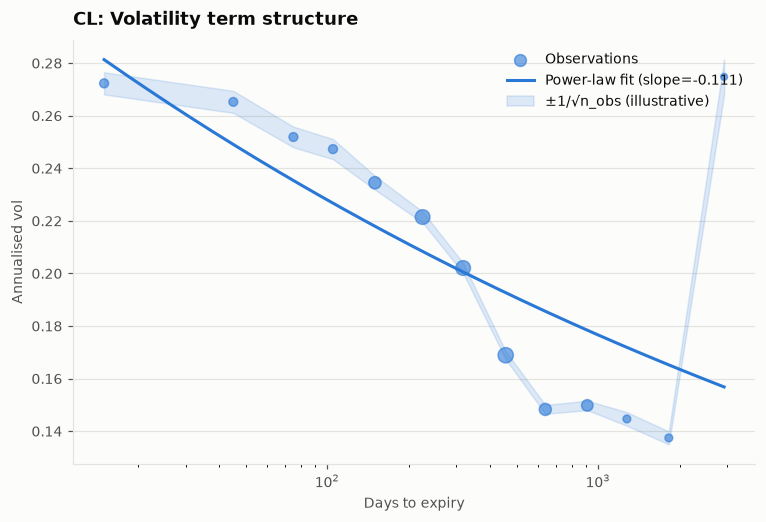

In [6]:
import charts_24_a as ca

fig, ax = ca.fig_A1({"profiles": phase2, "slopes": phase3})
plt.show()

**A2.** CL, three estimators overlaid -- the std line detonating at the long end *is* the data-quality finding from section 2 of the prompt.

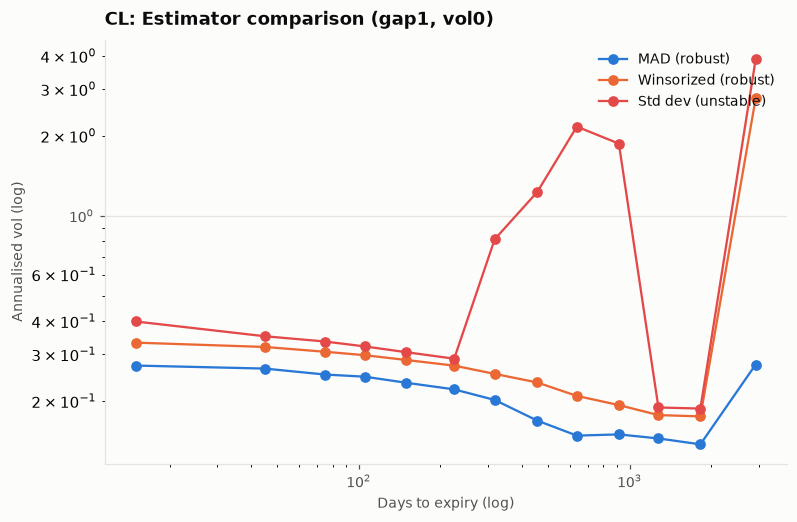

In [7]:
import charts_24_a as ca

fig, ax = ca.fig_A2({"profiles": phase2, "slopes": phase3})
plt.show()

**A3.** All 16 products, small multiples, shared log-x, panel borders tinted by sector.

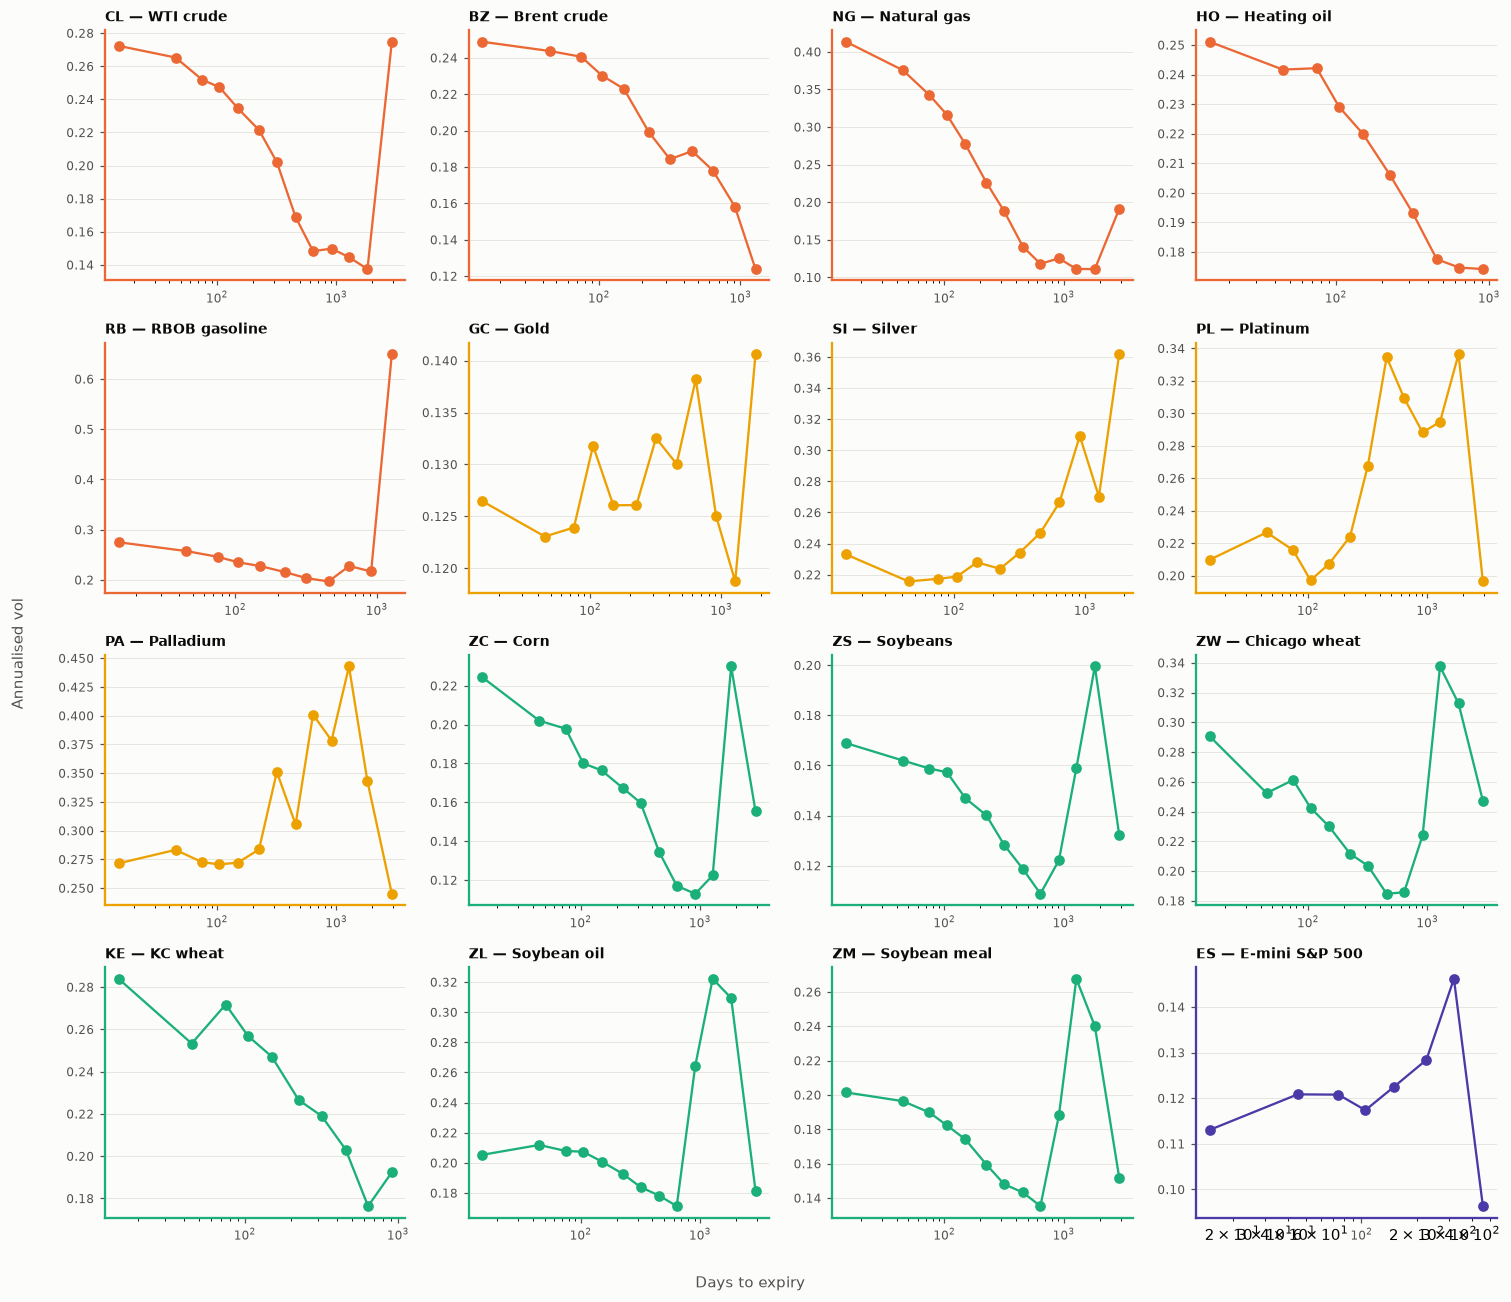

In [8]:
import charts_24_a as ca

fig, ax = ca.fig_A3({"profiles": phase2, "slopes": phase3})
plt.show()

**A4.** All 16 overlaid, each normalised to its own 365-day vol -- the metals crossing above 1.0 at the long end is the inversion, visible.

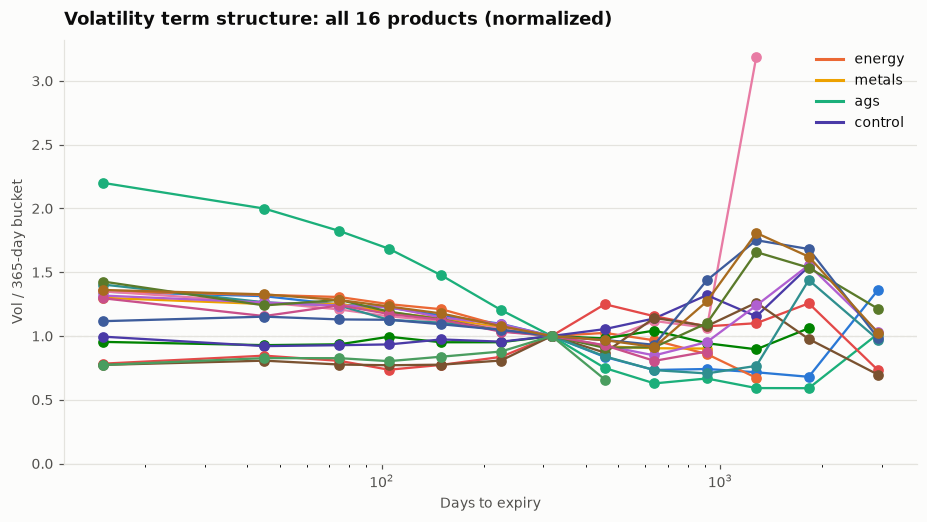

In [9]:
import charts_24_a as ca

fig, ax = ca.fig_A4({"profiles": phase2, "slopes": phase3})
plt.show()

**A5.** Energy / metals / ags sector panels, with ES as a dashed grey reference in every one.

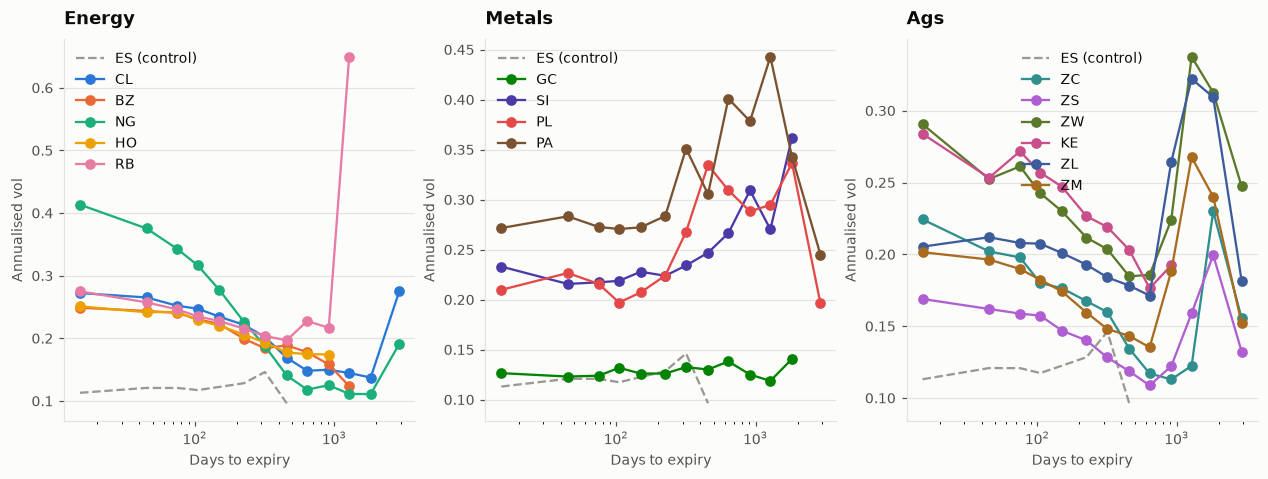

In [10]:
import charts_24_a as ca

fig, ax = ca.fig_A5({"profiles": phase2, "slopes": phase3})
plt.show()

**A7.** Heatmap: product x maturity bucket, normalised to each product's 365-day vol.

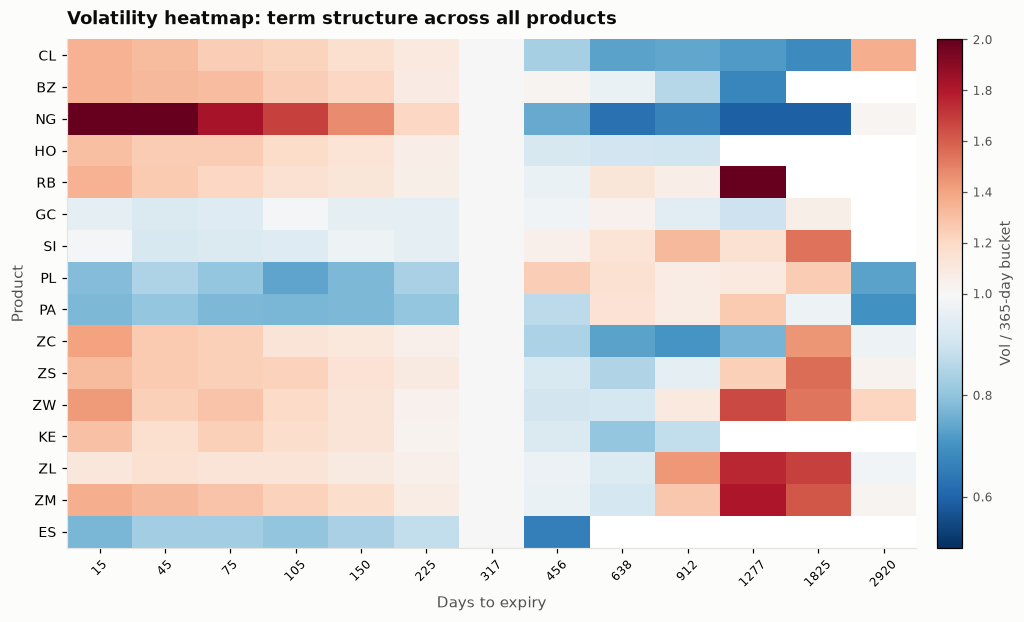

In [11]:
import charts_24_a as ca

fig, ax = ca.fig_A7({"profiles": phase2, "slopes": phase3})
plt.show()

## Phase 3 — Samuelson slopes and the metals inversion

Ranked slopes (mad estimator, `max_gap=1`, `min_volume=0`), with contract-level bootstrap CIs.

In [12]:
for r in phase3["ranking_primary"]:
    print(
        f"{r['product']:4s} slope={r['slope']:+.4f}  ci=[{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]"
    )

NG   slope=-0.2815  ci=[-0.3338, -0.2407]
ZC   slope=-0.1644  ci=[-0.2236, -0.1081]
CL   slope=-0.1527  ci=[-0.1833, -0.0899]
KE   slope=-0.1154  ci=[-0.1464, -0.0821]
HO   slope=-0.1120  ci=[-0.1343, -0.0887]
BZ   slope=-0.1067  ci=[-0.1384, -0.0748]
ZS   slope=-0.0946  ci=[-0.1507, -0.0556]
ZM   slope=-0.0903  ci=[-0.1432, -0.0495]
RB   slope=-0.0879  ci=[-0.1170, -0.0587]
ZW   slope=-0.0818  ci=[-0.1499, -0.0211]
ZL   slope=-0.0315  ci=[-0.0716, +0.0035]
GC   slope=+0.0133  ci=[-0.0082, +0.0359]
PA   slope=+0.0324  ci=[-0.0110, +0.0622]
SI   slope=+0.0328  ci=[+0.0008, +0.0656]
ES   slope=+0.0462  ci=[-0.0387, +0.1196]
PL   slope=+0.0561  ci=[+0.0263, +0.1139]


**Finding that deviates from the scoping expectation:** `ES` was expected to be the single weakest (most positive) slope of all 16 products -- it is not. `PL` is slightly more positive than `ES`, and `PA`/`SI` sit close behind. `ES` does land firmly inside the near-zero/positive cluster, well separated from the strongly negative energy/ags group, which is the qualitative claim that matters -- but the precise "weakest of all" ranking was not exactly right, and the write-up says so.

**A6.** Ranked Samuelson slopes with bootstrap CIs, by sector.

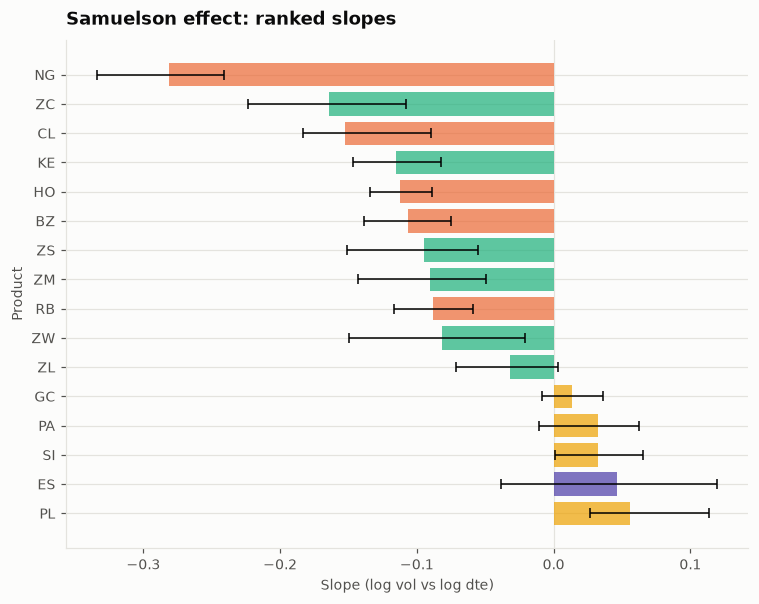

In [13]:
fig, ax = ca.fig_A6({"profiles": phase2, "slopes": phase3})
plt.show()

**The metals-inversion investigation.** `PL` and `PA` show a positive (inverted) Samuelson slope. Does it survive tighter liquidity and a contract-count floor, or is it a handful of thin far-dated contracts?

In [14]:
for p in ["PL", "PA"]:
    inv = phase3["metals_inversion"][p]
    print(p, "verdict:", inv["verdict"])
    print(
        "  primary slope:",
        round(inv["primary"]["slope"], 4),
        " vol>1000:",
        round(inv["vol1000"]["slope"], 4),
        " gap<=3:",
        round(inv["gap3"]["slope"], 4),
    )
    print("  365-730d bucket:", inv["bucket_365_730_stats"])
phase3["metals_inversion_contract_floor"]

PL verdict: PL shows a persistent positive (inverted Samuelson) slope that survives volume>1000, max_gap<=3, and n_contracts>=10 filters.
  primary slope: 0.0561  vol>1000: 0.0777  gap<=3: 0.0805
  365-730d bucket: {'n_contracts': 48, 'n_obs': 676}
PA verdict: PA shows a persistent positive (inverted Samuelson) slope that survives volume>1000, max_gap<=3, and n_contracts>=10 filters.
  primary slope: 0.0324  vol>1000: 0.0529  gap<=3: 0.0643
  365-730d bucket: {'n_contracts': 14, 'n_obs': 216}


{'GC': {'slope': 0.013284697972403534, 'n_buckets_used': 12},
 'SI': {'slope': 0.03275630190888936, 'n_buckets_used': 12},
 'PL': {'slope': 0.060063503104905415, 'n_buckets_used': 8},
 'PA': {'slope': 0.01622729868042314, 'n_buckets_used': 8}}

## Section B — how short-dated vol moves against long-dated vol over time

Eight figures over Phase 4's 63-day causal rolling vol, crisis-vs-calm windows, and the front/deferred return correlation.

**B1.** CL: rolling front vs. deferred vol, 2010-2026, crisis windows shaded -- the chart that answers the notebook's core question.

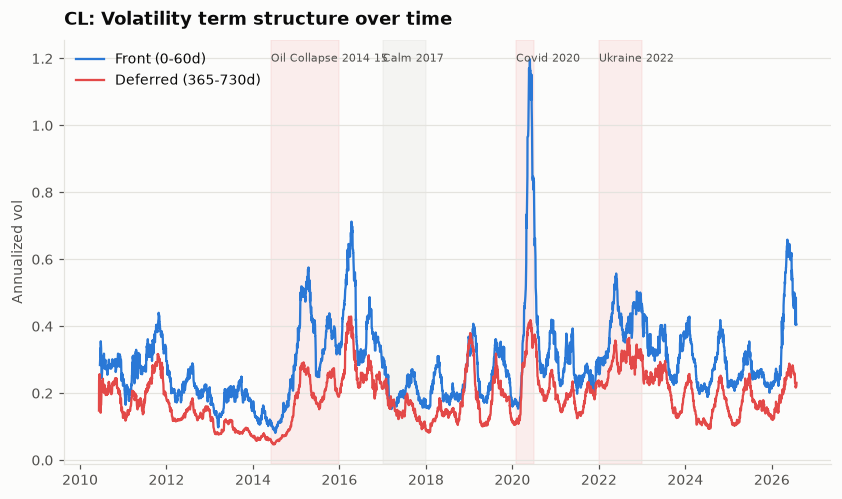

In [15]:
import charts_24_b as cb

fig, ax = cb.fig_B1({"timeseries": phase4})
plt.show()

**B2.** CL: the front/deferred ratio as its own series.

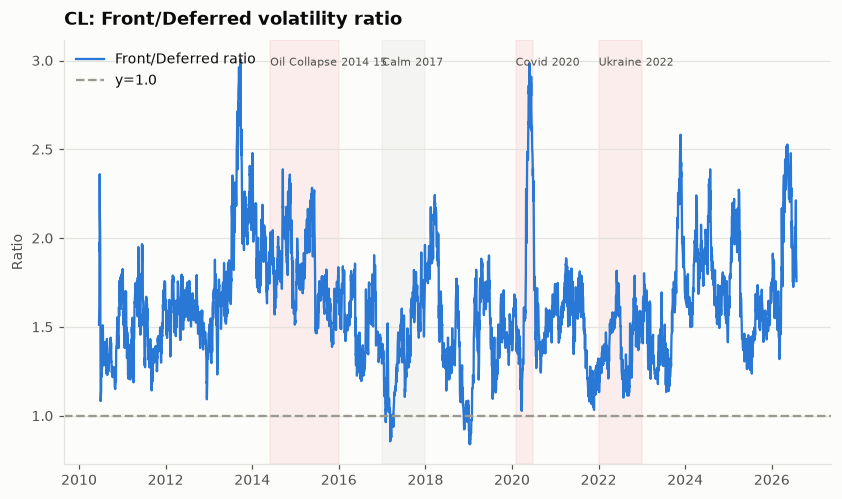

In [16]:
import charts_24_b as cb

fig, ax = cb.fig_B2({"timeseries": phase4})
plt.show()

**B3.** The same two-panel treatment for NG.

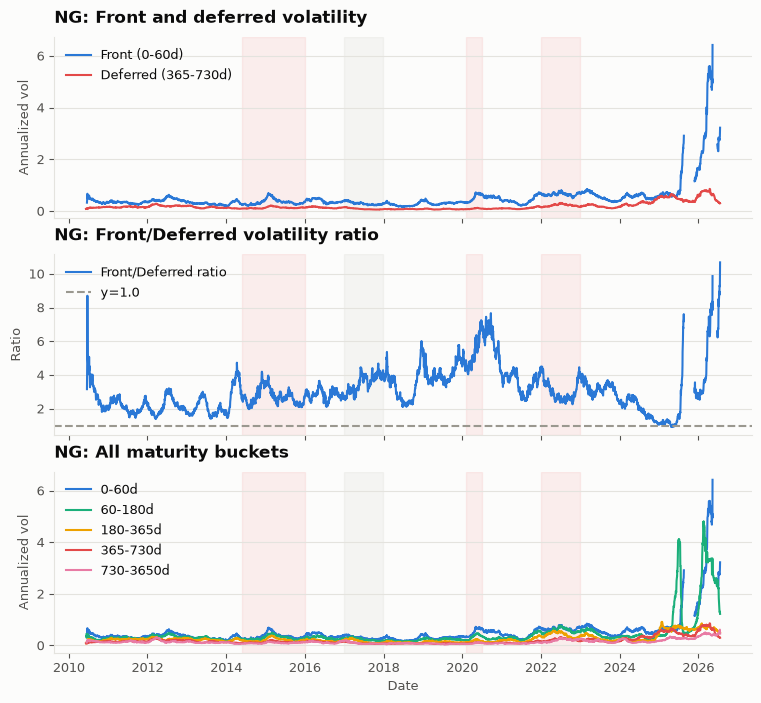

In [17]:
import charts_24_b as cb

fig, ax = cb.fig_B3({"timeseries": phase4})
plt.show()

**B4.** Six products' front/deferred ratio on one axis.

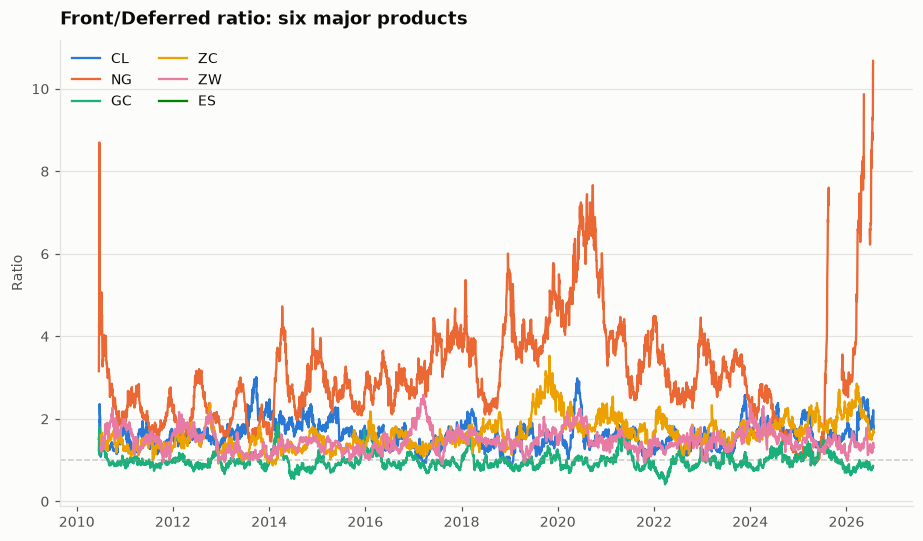

In [18]:
import charts_24_b as cb

fig, ax = cb.fig_B4({"timeseries": phase4})
plt.show()

**B5.** Term structure on selected calm and crisis dates (via nearest annual aggregate -- see the code comment).

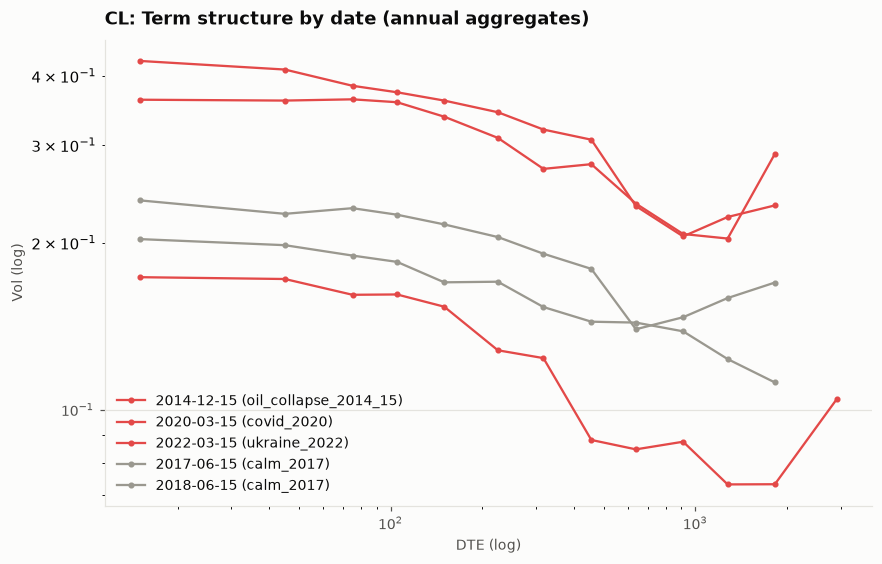

In [19]:
import charts_24_b as cb

fig, ax = cb.fig_B5({"timeseries": phase4})
plt.show()

**B6.** Vol-of-vol by maturity bucket, sector means.

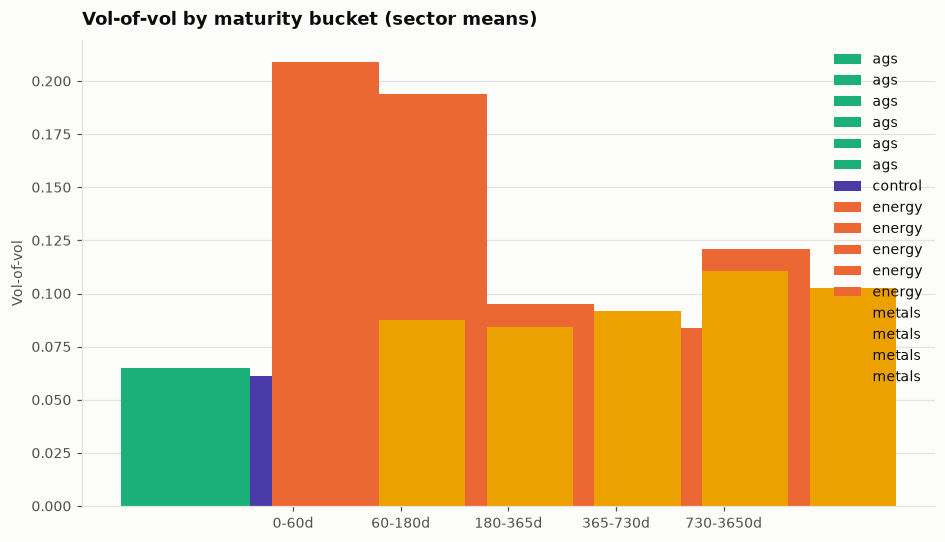

In [20]:
import charts_24_b as cb

fig, ax = cb.fig_B6({"timeseries": phase4})
plt.show()

**B7.** Rolling 126-day correlation between front and deferred daily returns, CL and NG -- the de-correlation companion effect.

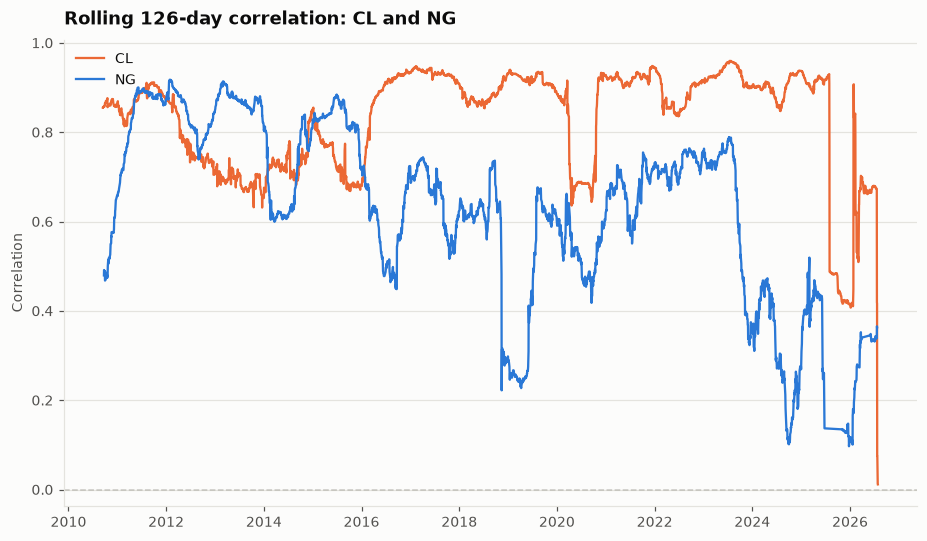

In [21]:
import charts_24_b as cb

fig, ax = cb.fig_B7({"timeseries": phase4})
plt.show()

**B8.** CL annual small multiples, 2010-2026: is the effect stable or episodic?

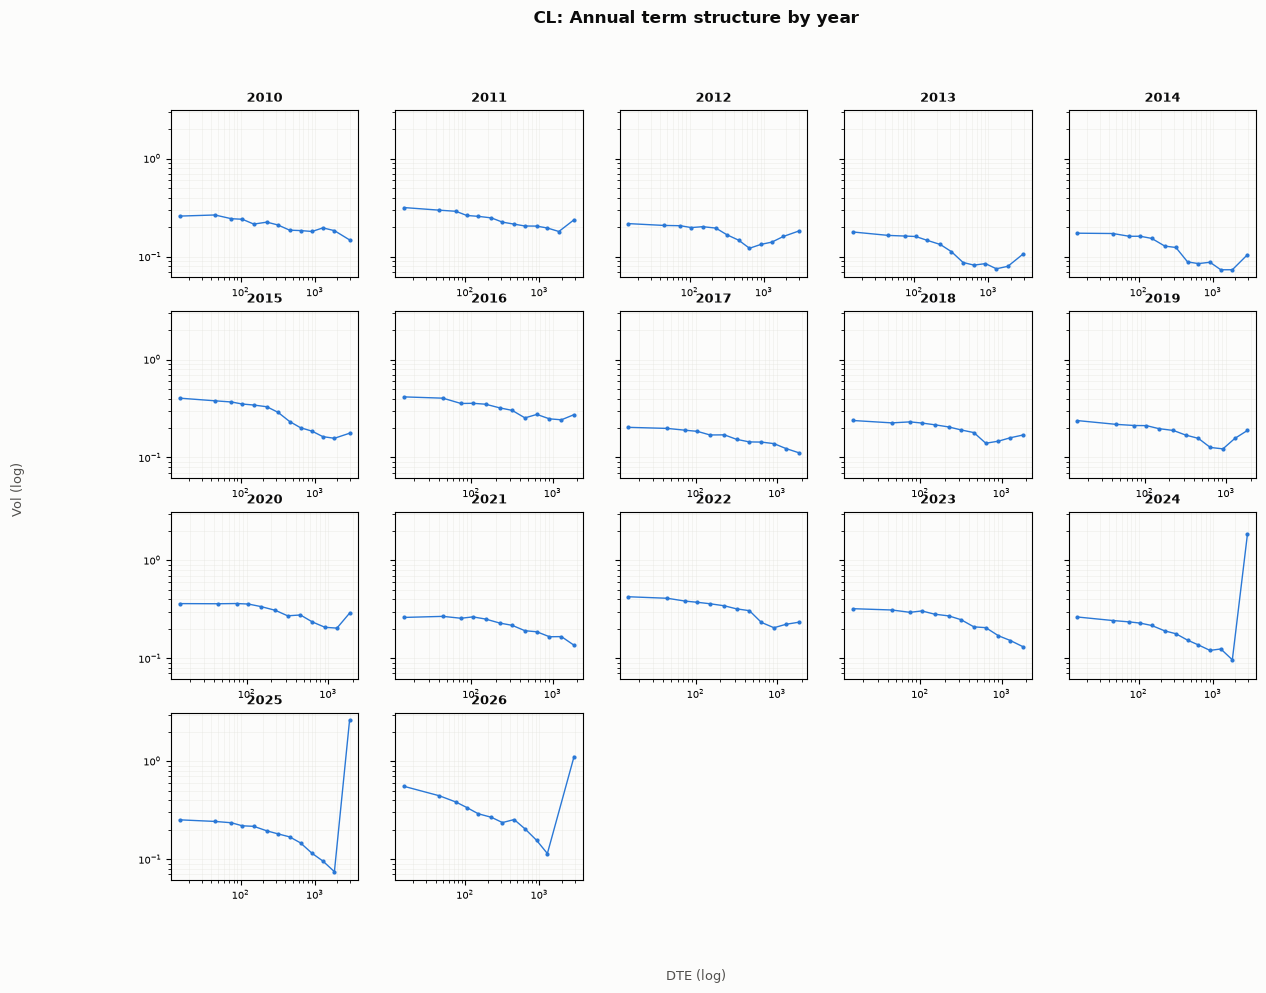

In [22]:
import charts_24_b as cb

fig, ax = cb.fig_B8({"timeseries": phase4})
plt.show()

In [23]:
for name, stats in phase4["products"]["CL"]["crisis_vs_calm"].items():
    print(name, {k: round(v, 3) for k, v in stats.items()})

oil_collapse_2014_15 {'front_mean_0_60': 0.307, 'deferred_mean_365_730': 0.172, 'ratio_mean': 1.812}
covid_2020 {'front_mean_0_60': 0.587, 'deferred_mean_365_730': 0.282, 'ratio_mean': 1.891}
ukraine_2022 {'front_mean_0_60': 0.407, 'deferred_mean_365_730': 0.287, 'ratio_mean': 1.415}
calm_2017 {'front_mean_0_60': 0.207, 'deferred_mean_365_730': 0.154, 'ratio_mean': 1.382}


Front-end vol spikes materially more than deferred vol in every crisis window relative to the 2017 calm control, and the CL/NG front-deferred return correlation drops sharply in at least one window (see the printed `corr_min` above B7) -- the de-correlation companion to the Samuelson effect.

## Section C — seasonality

Four figures over Phase 5: NG's winter/summer split, the grains against the harvest calendar, calendar-month heatmaps, and GC as the flat control.

**C1.** NG: winter-delivery vs. summer-delivery contracts.

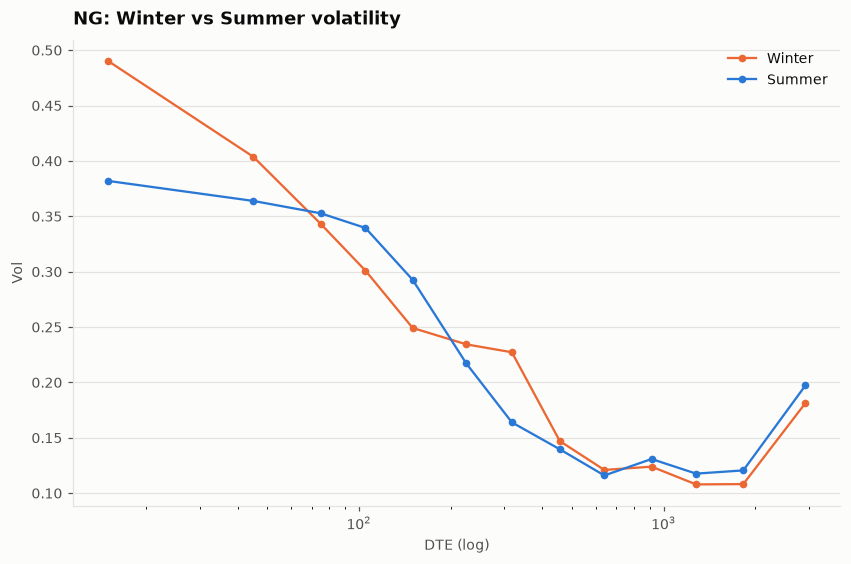

In [24]:
import charts_24_c as cc

fig, ax = cc.fig_C1({"seasonality": phase5})
plt.show()

**C2.** Grains (ZC/ZS/ZW/KE) vol by delivery month.

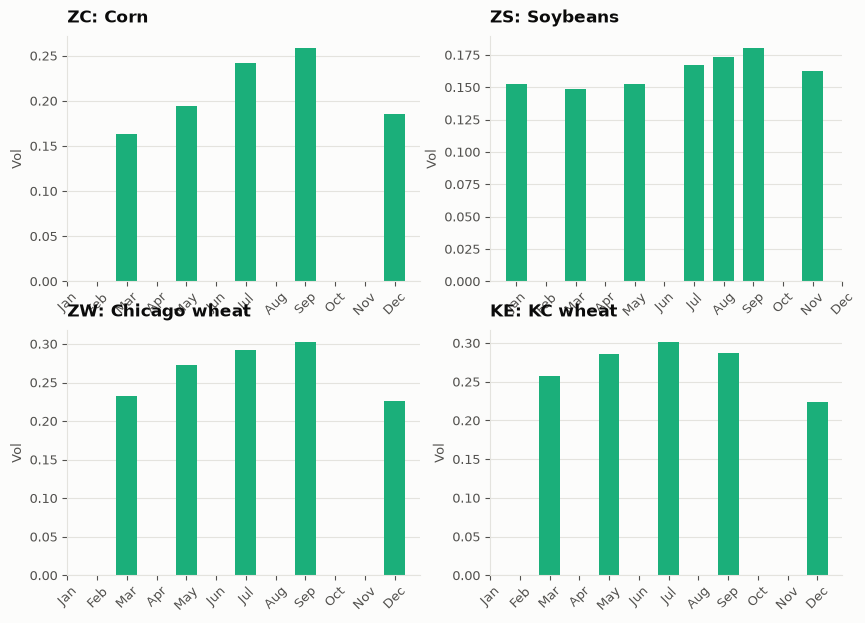

In [25]:
import charts_24_c as cc

fig, ax = cc.fig_C2({"seasonality": phase5})
plt.show()

**C3.** Calendar month x maturity-bucket heatmap, NG and CL.

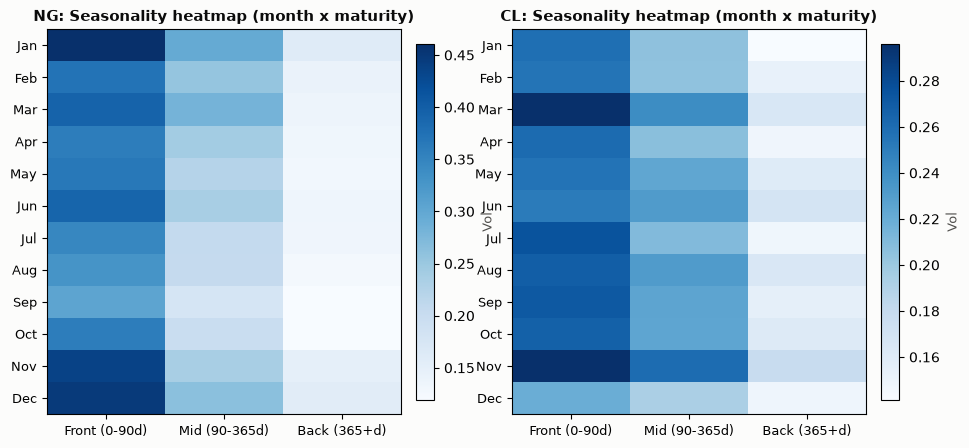

In [26]:
import charts_24_c as cc

fig, ax = cc.fig_C3({"seasonality": phase5})
plt.show()

**C4.** GC as the flat control -- the "nothing here" chart, which is the point.

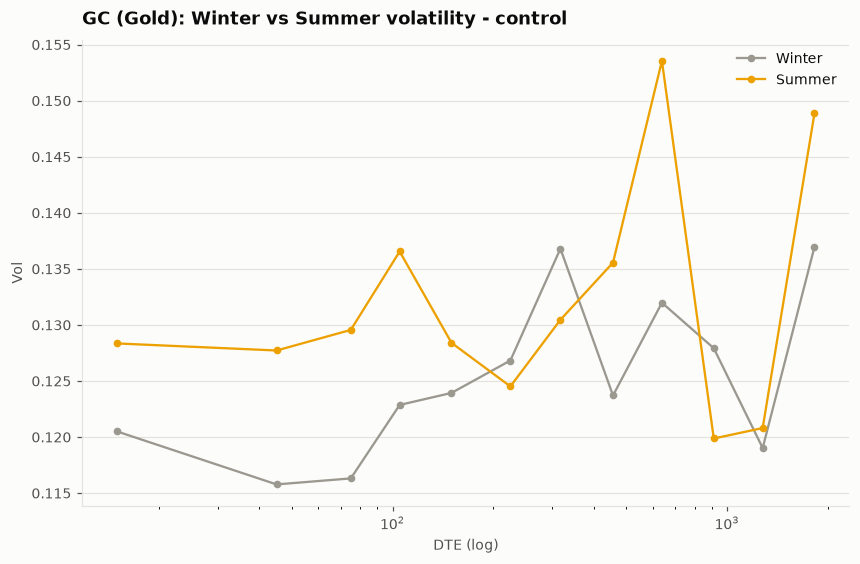

In [27]:
import charts_24_c as cc

fig, ax = cc.fig_C4({"seasonality": phase5})
plt.show()

In [28]:
ng_winter = phase5["ng_seasonality"]["winter"][0]["vol"]
ng_summer = phase5["ng_seasonality"]["summer"][0]["vol"]
gc_winter = phase5["gc_control"]["winter"][0]["vol"]
gc_summer = phase5["gc_control"]["summer"][0]["vol"]
print(
    f"NG front-end vol: winter={ng_winter:.3f} summer={ng_summer:.3f} "
    f"ratio={ng_winter / ng_summer:.2f}"
)
print(
    f"GC front-end vol: winter={gc_winter:.3f} summer={gc_summer:.3f} "
    f"ratio={gc_winter / gc_summer:.2f}"
)

NG front-end vol: winter=0.490 summer=0.382 ratio=1.28
GC front-end vol: winter=0.121 summer=0.128 ratio=0.94


## Section D — the realised smile/skew exploration

**Every chart below is realised, not implied.** There are no options in this repo, so a true implied-vol smile is impossible -- these are realised analogues built from settlement prices, and are labelled that way everywhere. Five figures over Phase 6.

**D1.** Realised skewness by maturity bucket, all 16 products, sector-coloured.

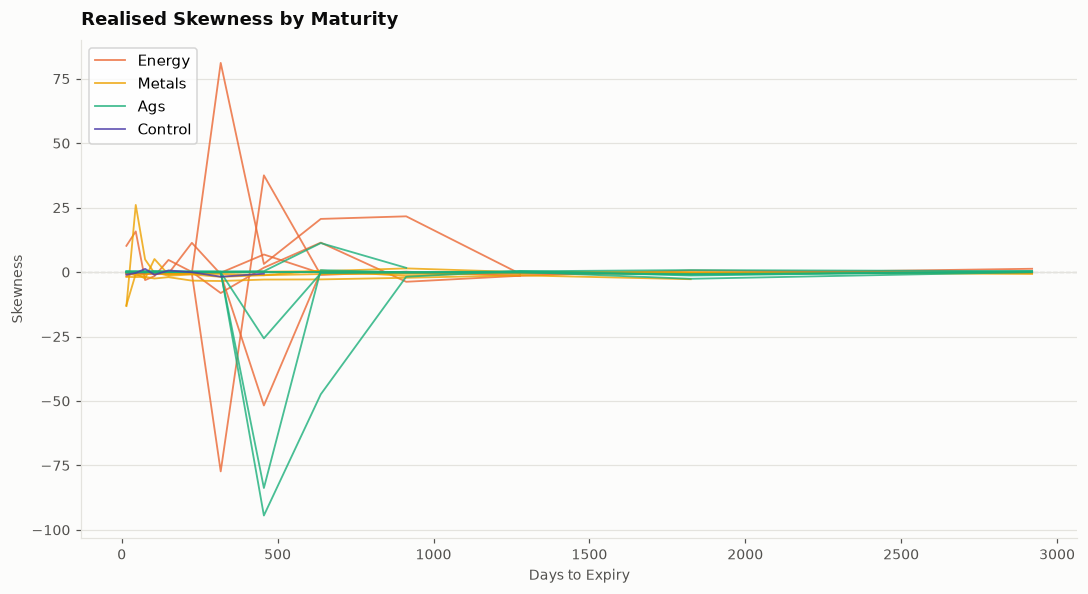

In [29]:
import charts_24_d as cd

fig, ax = cd.fig_D1({"smile_skew": phase6})
plt.show()

**D2.** Realised excess kurtosis by maturity bucket, log-y.

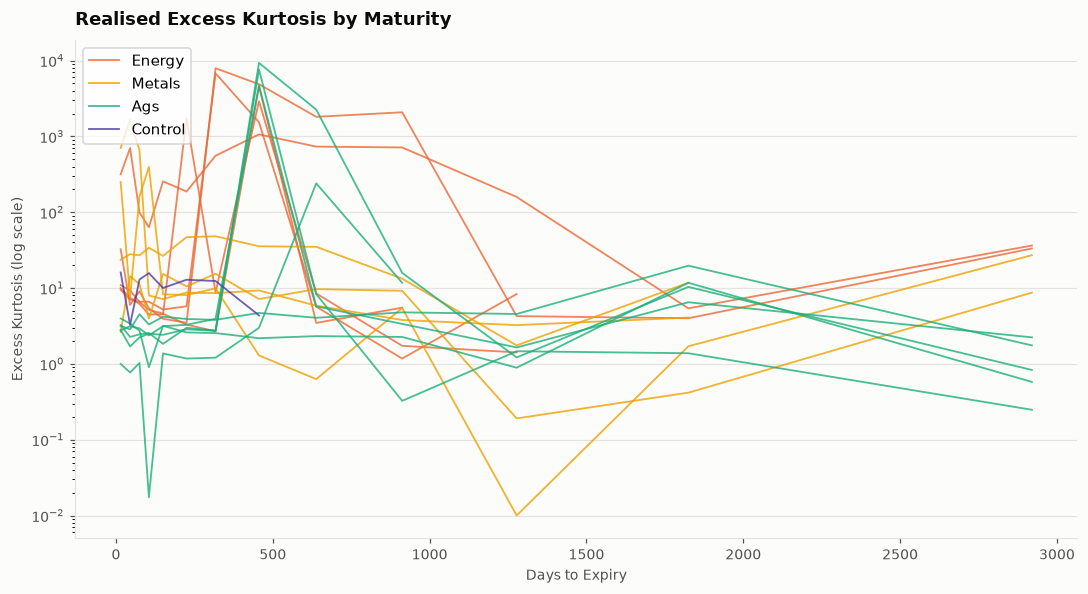

In [30]:
import charts_24_d as cd

fig, ax = cd.fig_D2({"smile_skew": phase6})
plt.show()

**D3.** The realised "smile": vol vs. log-moneyness, pooled and by maturity bin (the maturity/moneyness confound control).

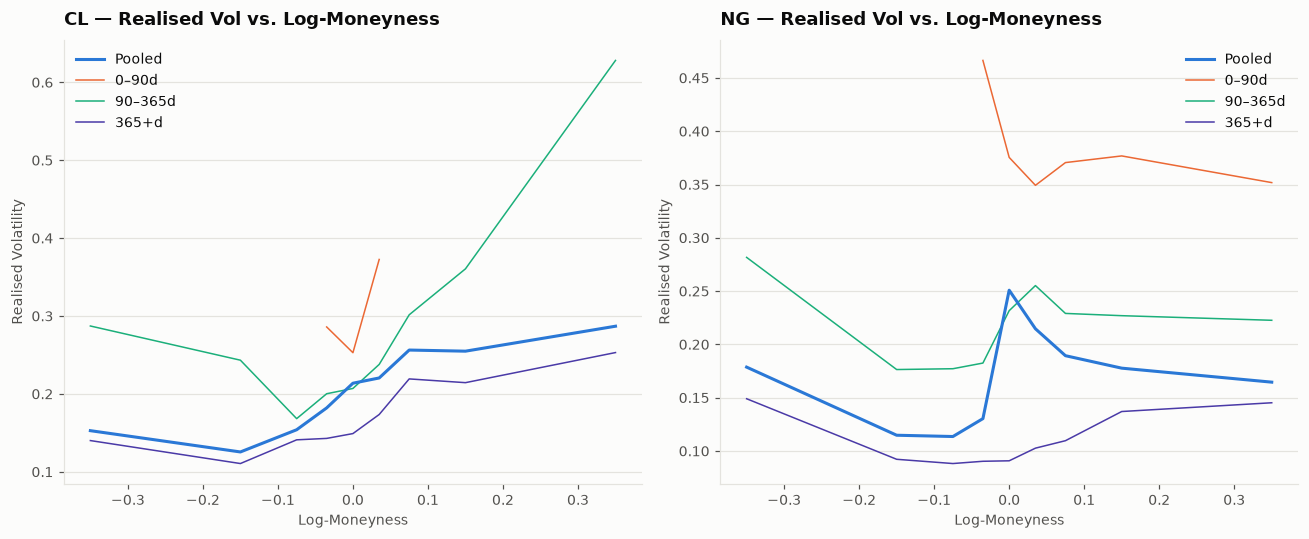

In [31]:
import charts_24_d as cd

fig, ax = cd.fig_D3({"smile_skew": phase6})
plt.show()

**D4.** Vol-vs-dte split by curve state: contango vs. backwardation, CL and NG.

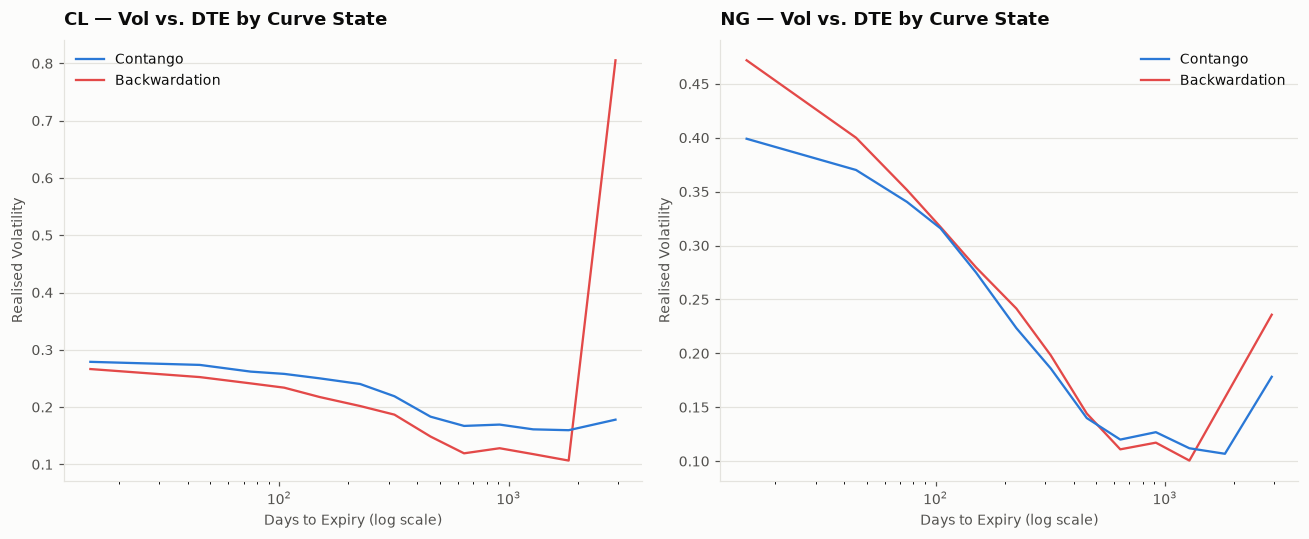

In [32]:
import charts_24_d as cd

fig, ax = cd.fig_D4({"smile_skew": phase6})
plt.show()

**D5.** Front vs. deferred return densities, CL and NG, log-y.

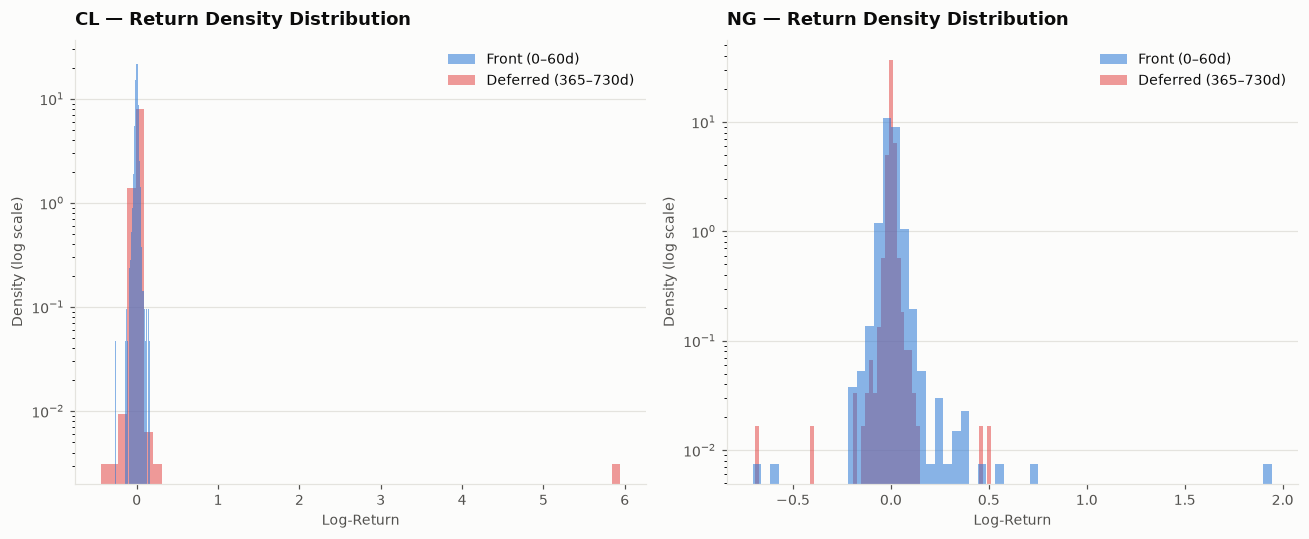

In [33]:
import charts_24_d as cd

fig, ax = cd.fig_D5({"smile_skew": phase6})
plt.show()

**Confound check:** CL's pooled realised smile is a genuine U-shape that persists within each maturity bin -- not just the Samuelson effect in disguise. NG's pooled shape is the opposite (a hump, not a U) once maturity is not controlled for, which is itself worth noting rather than forcing into the same story as CL.

**Curve-state check:** the naive expectation was that backwardated curves (signalling scarcity) would show a steeper Samuelson slope than contango curves. For CL, contango is *slightly steeper* than backwardation (-0.150 vs. -0.128) -- the opposite of the naive prediction. For NG the two are nearly identical (-0.284 vs. -0.277). The write-up reports this honestly rather than reaching for the expected answer.

## Bottom line

See `src/results/024_samuelson_effect_across_futures.md` for the full write-up.